# 视频生成：自静图至动影

---
**题名:** 视频生成

**门类:** video-generation

**难易:** 难

**所需时辰:** 约三刻

---

## 总论

生成一幅图像已属不易。生成**视频**——时间上连贯之图像序列——则难上加难。

核心之难：视频增一**时间维度**，万物倍之。内存、计算、保持一致性之难度，皆随帧数而增。一段 16 帧 512x512 之视频，其激活量为单幅图像之十六倍。

然近来之模型（Sora、CogVideo、HunyuanVideo）所生视频之连贯，堪称惊人。何以能然？

此篇所述者六：
1. 视频何以难：内存与计算之缩放
2. 时间注意力：模型如何跨时间推理
3. 产用架构：Sora、CogVideo、HunyuanVideo
4. 渐进训练：自图像至视频
5. 时间一致性：常见瑕疵与对策
6. 内存工程：如何使视频模型容于 GPU

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.formatting import info_box, comparison_table
from mp_tutorial.plantuml import render_plantuml
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 一、视频即图像加时间

视频者，帧（图像）之序列，随时间播放也。于神经网络而言，视频在图像张量之上增一**时间维度**：

- **图像**：(B, C, H, W)——如 (1, 3, 512, 512)
- **视频**：(B, C, **T**, H, W)——如 (1, 3, **16**, 512, 512)

其中 T 为帧数。此看似简单之增维，于内存与计算则影响甚巨。

In [2]:
# Memory scaling: how video multiplies everything
frames_list = [1, 4, 8, 16, 32, 64, 128]
H, W, C = 512, 512, 3
latent_H, latent_W, latent_C = 64, 64, 4

print("=== Raw Pixel Space ===")
print(f"{'Frames':>8} | {'Tensor Shape':>25} | {'Memory (FP16)':>15} | {'vs 1 frame':>12}")
print("-" * 70)
for T in frames_list:
    elements = C * T * H * W
    mem_mb = elements * 2 / (1024**2)
    print(f"{T:>8} | ({1}, {C}, {T:>3}, {H}, {W}) | {mem_mb:>12.1f} MB | {T:>10}x")

print("\n=== Latent Space ===")
print(f"{'Frames':>8} | {'Tensor Shape':>25} | {'Memory (FP16)':>15} | {'vs 1 frame':>12}")
print("-" * 70)
for T in frames_list:
    # Most models compress time too: T_latent = T / temporal_compress
    T_latent = max(1, T // 4)  # 4x temporal compression
    elements = latent_C * T_latent * latent_H * latent_W
    mem_mb = elements * 2 / (1024**2)
    print(f"{T:>8} | ({1}, {latent_C}, {T_latent:>3}, {latent_H}, {latent_W}) | {mem_mb:>12.1f} MB | {max(1, T//4):>10}x")

=== Raw Pixel Space ===
  Frames |              Tensor Shape |   Memory (FP16) |   vs 1 frame
----------------------------------------------------------------------
       1 | (1, 3,   1, 512, 512) |          1.5 MB |          1x
       4 | (1, 3,   4, 512, 512) |          6.0 MB |          4x
       8 | (1, 3,   8, 512, 512) |         12.0 MB |          8x
      16 | (1, 3,  16, 512, 512) |         24.0 MB |         16x
      32 | (1, 3,  32, 512, 512) |         48.0 MB |         32x
      64 | (1, 3,  64, 512, 512) |         96.0 MB |         64x
     128 | (1, 3, 128, 512, 512) |        192.0 MB |        128x

=== Latent Space ===
  Frames |              Tensor Shape |   Memory (FP16) |   vs 1 frame
----------------------------------------------------------------------
       1 | (1, 4,   1, 64, 64) |          0.0 MB |          1x
       4 | (1, 4,   1, 64, 64) |          0.0 MB |          1x
       8 | (1, 4,   2, 64, 64) |          0.1 MB |          2x
      16 | (1, 4,   4, 64, 6

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


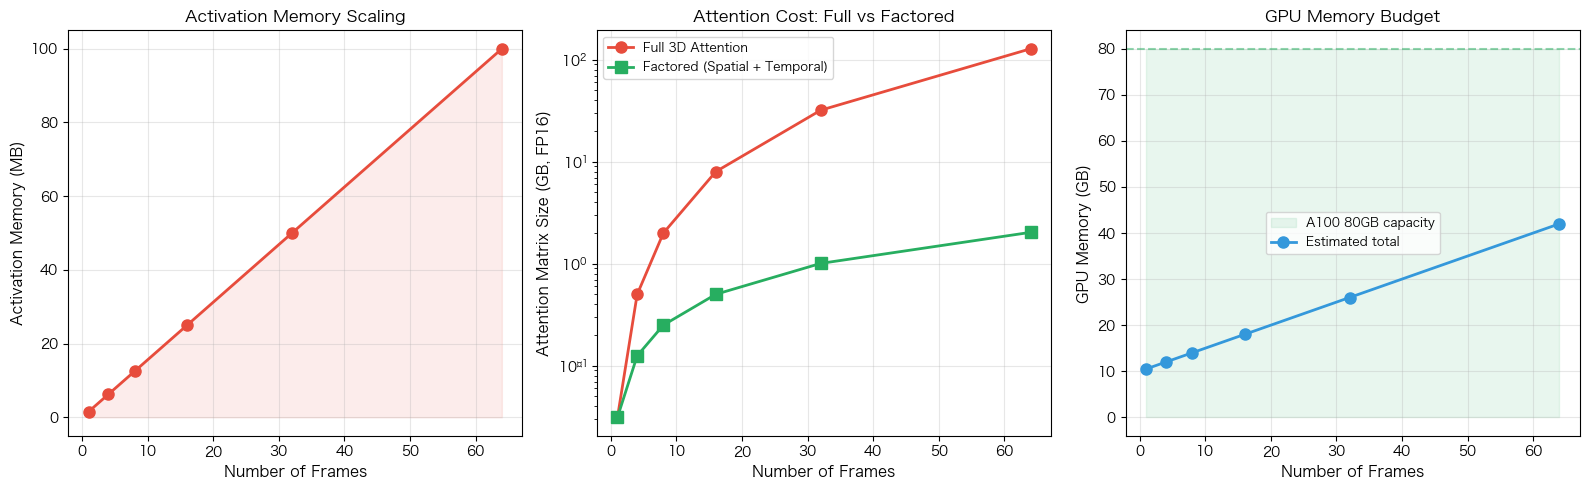

Key takeaway: full 3D attention is completely impractical for video.
At 16 frames with 64x64 spatial resolution, the attention matrix alone is ~64 GB!
Factored attention (spatial + temporal separately) reduces this to ~0.07 GB.


In [3]:
# Visualize memory scaling for different components
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

frames = [1, 4, 8, 16, 32, 64]

# Activation memory (assuming latent space with temporal compression)
ax = axes[0]
activation_per_frame = 64 * 64 * 4 * 2 / (1024**2)  # MB per latent frame (FP16)
# UNet/DiT activations are much larger due to intermediate features
model_activation_factor = 50  # typical ratio
act_memory = [T * activation_per_frame * model_activation_factor for T in frames]
ax.plot(frames, act_memory, 'o-', color='#E74C3C', linewidth=2, markersize=8)
ax.fill_between(frames, act_memory, alpha=0.1, color='#E74C3C')
ax.set_xlabel('Number of Frames', fontsize=11)
ax.set_ylabel('Activation Memory (MB)', fontsize=11)
ax.set_title('Activation Memory Scaling', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Self-attention cost: O(T^2 * S^2) for full 3D attention
ax = axes[1]
S = 64 * 64  # spatial tokens per frame
full_3d = [(T * S) ** 2 * 2 / (1024**3) for T in frames]  # GB for attention matrix
factored = [T * S**2 * 2 / (1024**3) + S * T**2 * 2 / (1024**3) for T in frames]

ax.plot(frames, full_3d, 'o-', color='#E74C3C', linewidth=2, markersize=8, label='Full 3D Attention')
ax.plot(frames, factored, 's-', color='#27AE60', linewidth=2, markersize=8, label='Factored (Spatial + Temporal)')
ax.set_xlabel('Number of Frames', fontsize=11)
ax.set_ylabel('Attention Matrix Size (GB, FP16)', fontsize=11)
ax.set_title('Attention Cost: Full vs Factored', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Total GPU memory estimate
ax = axes[2]
gpu_80gb = [80] * len(frames)
total_mem = [f * 0.5 + 10 for f in frames]  # rough: 0.5 GB/frame activations + 10 GB model

ax.fill_between(frames, gpu_80gb, alpha=0.1, color='#27AE60', label='A100 80GB capacity')
ax.axhline(y=80, color='#27AE60', linestyle='--', alpha=0.5)
ax.plot(frames, total_mem, 'o-', color='#3498DB', linewidth=2, markersize=8, label='Estimated total')
ax.set_xlabel('Number of Frames', fontsize=11)
ax.set_ylabel('GPU Memory (GB)', fontsize=11)
ax.set_title('GPU Memory Budget', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key takeaway: full 3D attention is completely impractical for video.")
print("At 16 frames with 64x64 spatial resolution, the attention matrix alone is ~64 GB!")
print("Factored attention (spatial + temporal separately) reduces this to ~0.07 GB.")

In [4]:
# Concrete memory breakdown for video generation
comparison_table(
    headers=["Component", "Image (1 frame)", "Video (16 frames)", "Video (64 frames)"],
    rows=[
        ["Input latent", "0.03 MB", "0.5 MB (4x temporal compress)", "2 MB"],
        ["Model weights (DiT-XL)", "~1.4 GB", "~1.4 GB (same model)", "~1.4 GB"],
        ["Activations (per layer)", "~8 MB", "~128 MB", "~512 MB"],
        ["Activations (28 layers)", "~224 MB", "~3.6 GB", "~14.3 GB"],
        ["Attention matrix (spatial)", "~32 MB", "~32 MB / frame", "~32 MB / frame"],
        ["Attention matrix (temporal)", "N/A", "~2 MB / position", "~32 MB / position"],
        ["Gradients (training)", "~1.4 GB", "~1.4 GB", "~1.4 GB"],
        ["Optimizer states", "~5.6 GB", "~5.6 GB", "~5.6 GB"],
        ["Total (inference)", "~1.7 GB", "~5.5 GB", "~17 GB"],
        ["Total (training)", "~8.7 GB", "~12.5 GB", "~24 GB"],
    ],
    title="Memory Breakdown: Image vs Video Generation"
)

print("\nNote: these are rough estimates for a DiT-XL scale model.")
print("Actual numbers vary significantly based on implementation details.")

Component,Image (1 frame),Video (16 frames),Video (64 frames)
Input latent,0.03 MB,0.5 MB (4x temporal compress),2 MB
Model weights (DiT-XL),~1.4 GB,~1.4 GB (same model),~1.4 GB
Activations (per layer),~8 MB,~128 MB,~512 MB
Activations (28 layers),~224 MB,~3.6 GB,~14.3 GB
Attention matrix (spatial),~32 MB,~32 MB / frame,~32 MB / frame
Attention matrix (temporal),N/A,~2 MB / position,~32 MB / position
Gradients (training),~1.4 GB,~1.4 GB,~1.4 GB
Optimizer states,~5.6 GB,~5.6 GB,~5.6 GB
Total (inference),~1.7 GB,~5.5 GB,~17 GB
Total (training),~8.7 GB,~12.5 GB,~24 GB



Note: these are rough estimates for a DiT-XL scale model.
Actual numbers vary significantly based on implementation details.


---
## 二、时间注意力

关键之问：模型当如何跨帧推理？

**全三维注意力**——各词元关注所有帧之所有词元——表达力最强，然计算量以总词元数（$T \times H \times W$）为底呈二次增长，代价过巨。

实用之法乃**分解注意力**，将注意力拆为二独立运算：

1. **空间注意力**：于各帧之内，词元关注**同帧**之其余词元（捕捉物体、构图、风格）
2. **时间注意力**：于各空间位置，跨**所有帧**于**同一位置**相互关注（捕捉运动、时间一致性）

如此将注意力自 $O((T \cdot S)^2)$ 降至 $O(T \cdot S^2 + S \cdot T^2)$——节省甚巨。

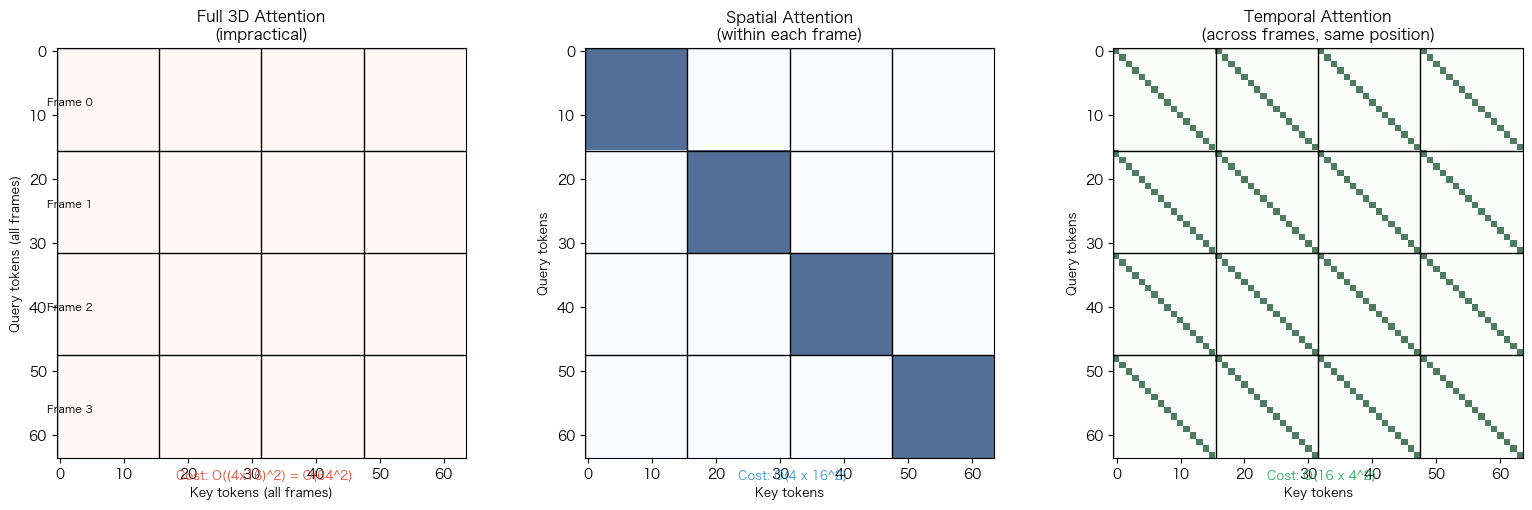

Factored attention = Spatial + Temporal (applied alternately)
The block-diagonal pattern of spatial attention is extremely cache-friendly.
The scattered pattern of temporal attention requires more careful implementation.


In [5]:
# Visualize factored attention: spatial vs temporal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Full 3D attention (for reference)
ax = axes[0]
ax.set_title('Full 3D Attention\n(impractical)', fontsize=11, fontweight='bold')
T, H, W = 4, 4, 4  # small for visualization
total_tokens = T * H * W
attn_matrix = np.ones((total_tokens, total_tokens))
ax.imshow(attn_matrix, cmap='Reds', alpha=0.7)
for t in range(T):
    pos = t * H * W
    ax.axhline(pos - 0.5, color='black', linewidth=1)
    ax.axvline(pos - 0.5, color='black', linewidth=1)
    ax.text(-2, pos + H*W/2, f'Frame {t}', fontsize=8, va='center')
ax.set_xlabel('Key tokens (all frames)', fontsize=9)
ax.set_ylabel('Query tokens (all frames)', fontsize=9)
ax.text(total_tokens/2, total_tokens + 3, f'Cost: O(({T}x{H*W})^2) = O({total_tokens}^2)',
        ha='center', fontsize=9, color='#E74C3C')

# Spatial attention (within each frame)
ax = axes[1]
ax.set_title('Spatial Attention\n(within each frame)', fontsize=11, fontweight='bold')
attn_matrix = np.zeros((total_tokens, total_tokens))
for t in range(T):
    start = t * H * W
    end = start + H * W
    attn_matrix[start:end, start:end] = 1.0
ax.imshow(attn_matrix, cmap='Blues', alpha=0.7)
for t in range(T):
    pos = t * H * W
    ax.axhline(pos - 0.5, color='black', linewidth=1)
    ax.axvline(pos - 0.5, color='black', linewidth=1)
ax.set_xlabel('Key tokens', fontsize=9)
ax.set_ylabel('Query tokens', fontsize=9)
ax.text(total_tokens/2, total_tokens + 3, f'Cost: O({T} x {H*W}^2)',
        ha='center', fontsize=9, color='#3498DB')

# Temporal attention (across frames at same position)
ax = axes[2]
ax.set_title('Temporal Attention\n(across frames, same position)', fontsize=11, fontweight='bold')
attn_matrix = np.zeros((total_tokens, total_tokens))
for s in range(H * W):
    for t1 in range(T):
        for t2 in range(T):
            attn_matrix[t1 * H * W + s, t2 * H * W + s] = 1.0
ax.imshow(attn_matrix, cmap='Greens', alpha=0.7)
for t in range(T):
    pos = t * H * W
    ax.axhline(pos - 0.5, color='black', linewidth=1)
    ax.axvline(pos - 0.5, color='black', linewidth=1)
ax.set_xlabel('Key tokens', fontsize=9)
ax.set_ylabel('Query tokens', fontsize=9)
ax.text(total_tokens/2, total_tokens + 3, f'Cost: O({H*W} x {T}^2)',
        ha='center', fontsize=9, color='#27AE60')

plt.tight_layout()
plt.show()

print("Factored attention = Spatial + Temporal (applied alternately)")
print("The block-diagonal pattern of spatial attention is extremely cache-friendly.")
print("The scattered pattern of temporal attention requires more careful implementation.")

In [6]:
class FactoredAttention(nn.Module):
    """Factored spatial + temporal attention for video.
    
    Instead of attending to all T*H*W tokens at once (O((T*H*W)^2)),
    we do:
    1. Spatial attention: each frame attends within itself (O(T * (H*W)^2))
    2. Temporal attention: each spatial position attends across frames (O(H*W * T^2))
    """
    def __init__(self, dim, n_heads=4):
        super().__init__()
        self.dim = dim
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.scale = self.head_dim ** -0.5
        
        # Spatial attention
        self.spatial_qkv = nn.Linear(dim, 3 * dim)
        self.spatial_proj = nn.Linear(dim, dim)
        
        # Temporal attention
        self.temporal_qkv = nn.Linear(dim, 3 * dim)
        self.temporal_proj = nn.Linear(dim, dim)
        
        self.norm_s = nn.LayerNorm(dim)
        self.norm_t = nn.LayerNorm(dim)
    
    def _attention(self, qkv_proj, out_proj, x):
        B, N, D = x.shape
        qkv = qkv_proj(x).reshape(B, N, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return out_proj(out)
    
    def forward(self, x, T, H, W):
        """
        x: (B, T*H*W, D) -- flattened video tokens
        T: number of frames
        H, W: spatial dimensions (in patches)
        """
        B, N, D = x.shape
        S = H * W  # spatial tokens per frame
        
        # 1. Spatial attention: reshape to (B*T, S, D)
        x_spatial = self.norm_s(x)
        x_spatial = x_spatial.reshape(B * T, S, D)
        spatial_out = self._attention(self.spatial_qkv, self.spatial_proj, x_spatial)
        spatial_out = spatial_out.reshape(B, T * S, D)
        x = x + spatial_out
        
        # 2. Temporal attention: reshape to (B*S, T, D)
        x_temporal = self.norm_t(x)
        x_temporal = x_temporal.reshape(B, T, S, D).permute(0, 2, 1, 3).reshape(B * S, T, D)
        temporal_out = self._attention(self.temporal_qkv, self.temporal_proj, x_temporal)
        temporal_out = temporal_out.reshape(B, S, T, D).permute(0, 2, 1, 3).reshape(B, T * S, D)
        x = x + temporal_out
        
        return x

# Demo with real tensors
torch.manual_seed(42)
B, T, H, W, D = 1, 8, 8, 8, 128  # 8 frames, 8x8 patches, 128-dim
factored_attn = FactoredAttention(dim=D, n_heads=4)

x = torch.randn(B, T * H * W, D)  # flattened video tokens

with torch.no_grad():
    out = factored_attn(x, T=T, H=H, W=W)

print(f"Input:  {list(x.shape)} = ({B}, {T}*{H}*{W}, {D})")
print(f"Output: {list(out.shape)}")
print(f"\nSpatial attention:  ({B}*{T}, {H*W}, {D}) -> {B*T} independent attention ops of size {H*W}")
print(f"Temporal attention: ({B}*{H*W}, {T}, {D}) -> {B*H*W} independent attention ops of size {T}")
print(f"\nFull 3D attention cost:    {(T*H*W)**2 * D:>12,} operations")
print(f"Factored attention cost:   {T * (H*W)**2 * D + H*W * T**2 * D:>12,} operations")
print(f"Savings:                   {(T*H*W)**2 / (T * (H*W)**2 + H*W * T**2):.0f}x")

Input:  [1, 512, 128] = (1, 8*8*8, 128)
Output: [1, 512, 128]

Spatial attention:  (1*8, 64, 128) -> 8 independent attention ops of size 64
Temporal attention: (1*64, 8, 128) -> 64 independent attention ops of size 8

Full 3D attention cost:      33,554,432 operations
Factored attention cost:      4,718,592 operations
Savings:                   7x


In [7]:
# Compare different temporal modeling approaches
comparison_table(
    headers=["Approach", "Cost", "Quality", "Used In"],
    rows=[
        ["Full 3D Attention", "O((T*S)^2) -- prohibitive", "Best (sees everything)", "Not used in practice at scale"],
        ["Factored (Spatial + Temporal)", "O(T*S^2 + S*T^2)", "Very good", "Most video DiTs, CogVideo"],
        ["3D Convolution (C3D)", "O(T*S*k^3) per layer", "Good for local motion", "Early video models, as supplement"],
        ["Temporal Transformer layers", "O(S*T^2) -- temporal only", "Good for motion", "Sora, HunyuanVideo"],
        ["Causal temporal attention", "O(S * T*(T+1)/2)", "Good + autoregressive", "Some streaming models"],
    ],
    title="Temporal Modeling Approaches"
)

Approach,Cost,Quality,Used In
Full 3D Attention,O((T*S)^2) -- prohibitive,Best (sees everything),Not used in practice at scale
Factored (Spatial + Temporal),O(T*S^2 + S*T^2),Very good,"Most video DiTs, CogVideo"
3D Convolution (C3D),O(T*S*k^3) per layer,Good for local motion,"Early video models, as supplement"
Temporal Transformer layers,O(S*T^2) -- temporal only,Good for motion,"Sora, HunyuanVideo"
Causal temporal attention,O(S * T*(T+1)/2),Good + autoregressive,Some streaming models


---
## 三、产用架构

今析三大视频生成架构之工程层面。此等模型以[张量并行](../../lzh/02-tensor-parallelism.ipynb)与[流水线并行](../../lzh/03-pipeline-parallelism.ipynb)训练于数百 GPU 之上。

In [8]:
# Sora 架构总览（据公开技术报告）
info_box(
    """<b>Sora（OpenAI，2024）</b><br><br>
    <b>核心洞见：</b>将视频视为<i>时空图块</i>之网格——三维图块同时跨越空间与时间。<br><br>
    <b>架构要点：</b>
    <ul>
    <li><b>时空图块化</b>：将视频压缩为三维图块（如 2x8x8，覆 2 帧与 8x8 像素）</li>
    <li><b>DiT 骨干</b>：标准 Transformer 块处理全部时空词元</li>
    <li><b>可变分辨率</b>：可生成不同宽高比与时长</li>
    <li><b>时间压缩</b>：时间 VAE 于时间维亦行压缩（非仅空间）</li>
    </ul>
    <b>训练规模：</b>估计数千 GPU，以百万视频训之""",
    title="架构聚焦"
)

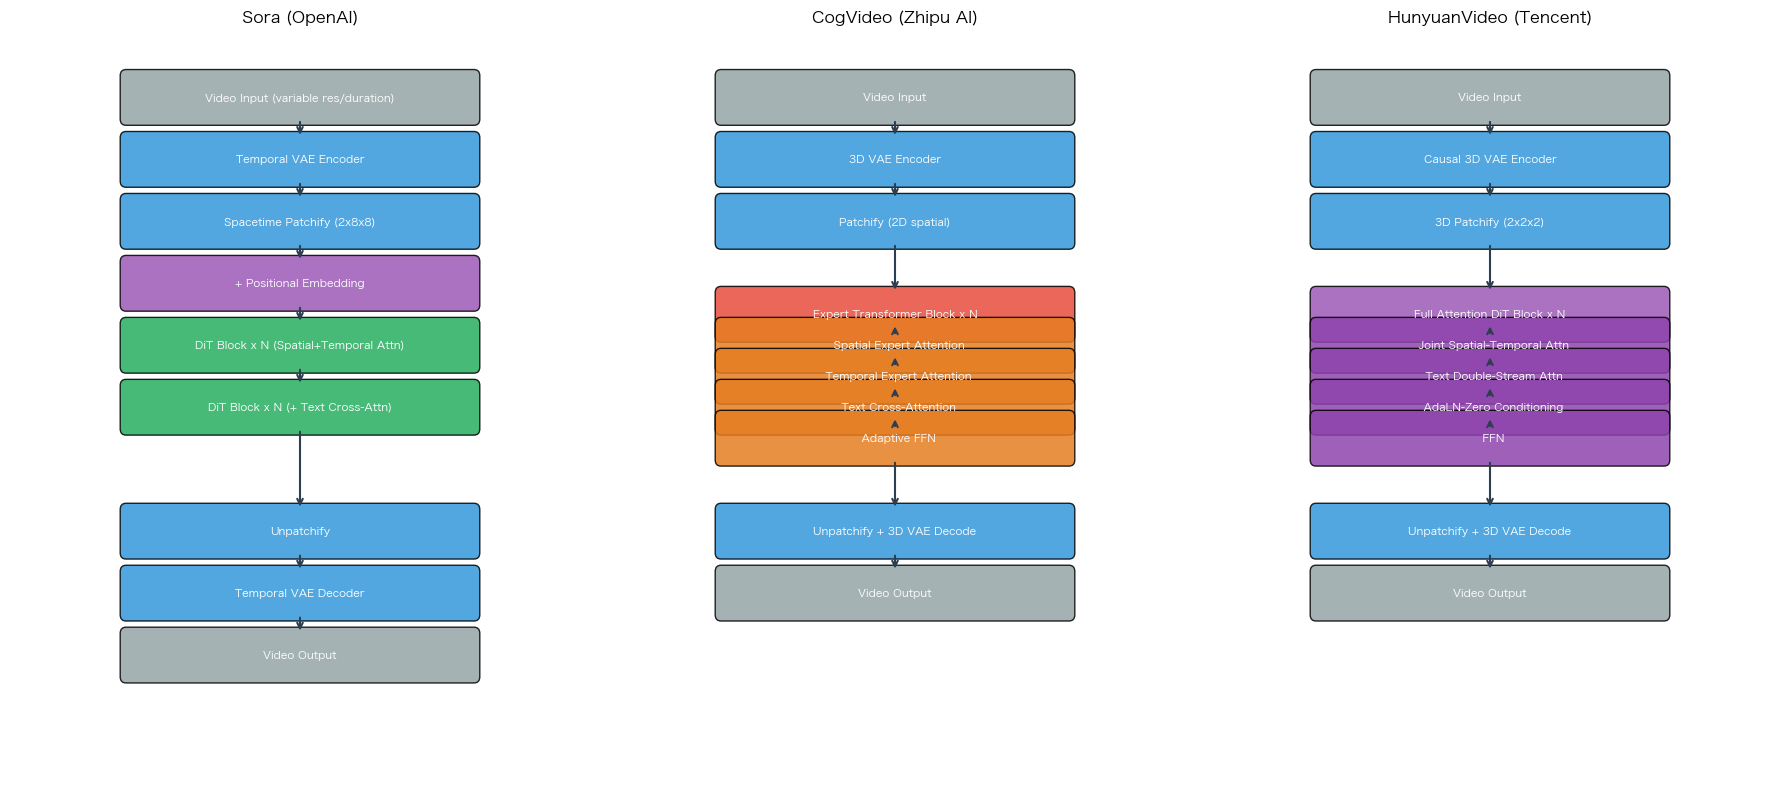

In [9]:
# Compare architectures side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

def draw_arch(ax, title, blocks, color):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    for i, (label, y, c) in enumerate(blocks):
        w = 6
        rect = mpatches.FancyBboxPatch((2, y-0.35), w, 0.7,
                                         boxstyle="round,pad=0.1", facecolor=c, alpha=0.85)
        ax.add_patch(rect)
        ax.text(5, y, label, ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        if i < len(blocks) - 1:
            next_y = blocks[i+1][1]
            ax.annotate('', xy=(5, next_y + 0.35), xytext=(5, y - 0.35),
                        arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

# Sora
sora_blocks = [
    ('Video Input (variable res/duration)', 11, '#95A5A6'),
    ('Temporal VAE Encoder', 10, '#3498DB'),
    ('Spacetime Patchify (2x8x8)', 9, '#3498DB'),
    ('+ Positional Embedding', 8, '#9B59B6'),
    ('DiT Block x N (Spatial+Temporal Attn)', 7, '#27AE60'),
    ('DiT Block x N (+ Text Cross-Attn)', 6, '#27AE60'),
    ('Unpatchify', 4, '#3498DB'),
    ('Temporal VAE Decoder', 3, '#3498DB'),
    ('Video Output', 2, '#95A5A6'),
]
draw_arch(axes[0], 'Sora (OpenAI)', sora_blocks, '#27AE60')

# CogVideo
cog_blocks = [
    ('Video Input', 11, '#95A5A6'),
    ('3D VAE Encoder', 10, '#3498DB'),
    ('Patchify (2D spatial)', 9, '#3498DB'),
    ('Expert Transformer Block x N', 7.5, '#E74C3C'),
    ('  Spatial Expert Attention', 7, '#E67E22'),
    ('  Temporal Expert Attention', 6.5, '#E67E22'),
    ('  Text Cross-Attention', 6, '#E67E22'),
    ('  Adaptive FFN', 5.5, '#E67E22'),
    ('Unpatchify + 3D VAE Decode', 4, '#3498DB'),
    ('Video Output', 3, '#95A5A6'),
]
draw_arch(axes[1], 'CogVideo (Zhipu AI)', cog_blocks, '#E74C3C')

# HunyuanVideo
hunyuan_blocks = [
    ('Video Input', 11, '#95A5A6'),
    ('Causal 3D VAE Encoder', 10, '#3498DB'),
    ('3D Patchify (2x2x2)', 9, '#3498DB'),
    ('Full Attention DiT Block x N', 7.5, '#9B59B6'),
    ('  Joint Spatial-Temporal Attn', 7, '#8E44AD'),
    ('  Text Double-Stream Attn', 6.5, '#8E44AD'),
    ('  AdaLN-Zero Conditioning', 6, '#8E44AD'),
    ('  FFN', 5.5, '#8E44AD'),
    ('Unpatchify + 3D VAE Decode', 4, '#3498DB'),
    ('Video Output', 3, '#95A5A6'),
]
draw_arch(axes[2], 'HunyuanVideo (Tencent)', hunyuan_blocks, '#9B59B6')

plt.tight_layout()
plt.show()

In [10]:
comparison_table(
    headers=["Feature", "Sora", "CogVideo", "HunyuanVideo"],
    rows=[
        ["Backbone", "DiT", "Expert Transformer", "Full-attention DiT"],
        ["Temporal modeling", "Spacetime patches + factored attn", "Factored spatial/temporal experts", "Joint spacetime attention"],
        ["Text conditioning", "Cross-attention (T5)", "Cross-attention", "Double-stream attention (LLAMA)"],
        ["Temporal VAE", "Yes (4x temporal compress)", "3D VAE (4x)", "Causal 3D VAE (4x)"],
        ["Patch strategy", "3D spacetime (2x8x8)", "2D spatial only", "3D (2x2x2)"],
        ["Resolution", "Variable", "Fixed per config", "Variable"],
        ["Key innovation", "Spacetime patches, variable res", "Expert routing for efficiency", "Causal VAE, dual-stream text"],
        ["Training GPUs", "Thousands (estimated)", "~256 A100s", "~512 A100s"],
    ],
    title="Video Generation Architecture Comparison"
)

print("\nCommon patterns across all architectures:")
print("1. ALL use a 3D VAE to compress video in both space and time")
print("2. ALL separate or factor spatial and temporal attention in some way")
print("3. ALL use text conditioning (cross-attention or joint attention)")
print("4. ALL require massive distributed training (hundreds of GPUs)")

Feature,Sora,CogVideo,HunyuanVideo
Backbone,DiT,Expert Transformer,Full-attention DiT
Temporal modeling,Spacetime patches + factored attn,Factored spatial/temporal experts,Joint spacetime attention
Text conditioning,Cross-attention (T5),Cross-attention,Double-stream attention (LLAMA)
Temporal VAE,Yes (4x temporal compress),3D VAE (4x),Causal 3D VAE (4x)
Patch strategy,3D spacetime (2x8x8),2D spatial only,3D (2x2x2)
Resolution,Variable,Fixed per config,Variable
Key innovation,"Spacetime patches, variable res",Expert routing for efficiency,"Causal VAE, dual-stream text"
Training GPUs,Thousands (estimated),~256 A100s,~512 A100s



Common patterns across all architectures:
1. ALL use a 3D VAE to compress video in both space and time
2. ALL separate or factor spatial and temporal attention in some way
3. ALL use text conditioning (cross-attention or joint attention)
4. ALL require massive distributed training (hundreds of GPUs)


---
## 四、渐进训练

从零训练视频模型极为艰难。通行之法乃**渐进训练**：

1. **第一阶段：图像预训练**——先以图像生成器训之（T=1）。此阶段学视觉品质、构图及文本理解。
2. **第二阶段：短视频**——以短片微调（4-16 帧）。模型学基本之运动。
3. **第三阶段：长视频**——延展至更长序列（32-128+ 帧）。模型学持续之运动与时间连贯。

何以能行：学视觉品质较学运动为「易」。若同时学二者，模型则二者俱困。分而学之，各阶段皆有更明晰之学习信号。

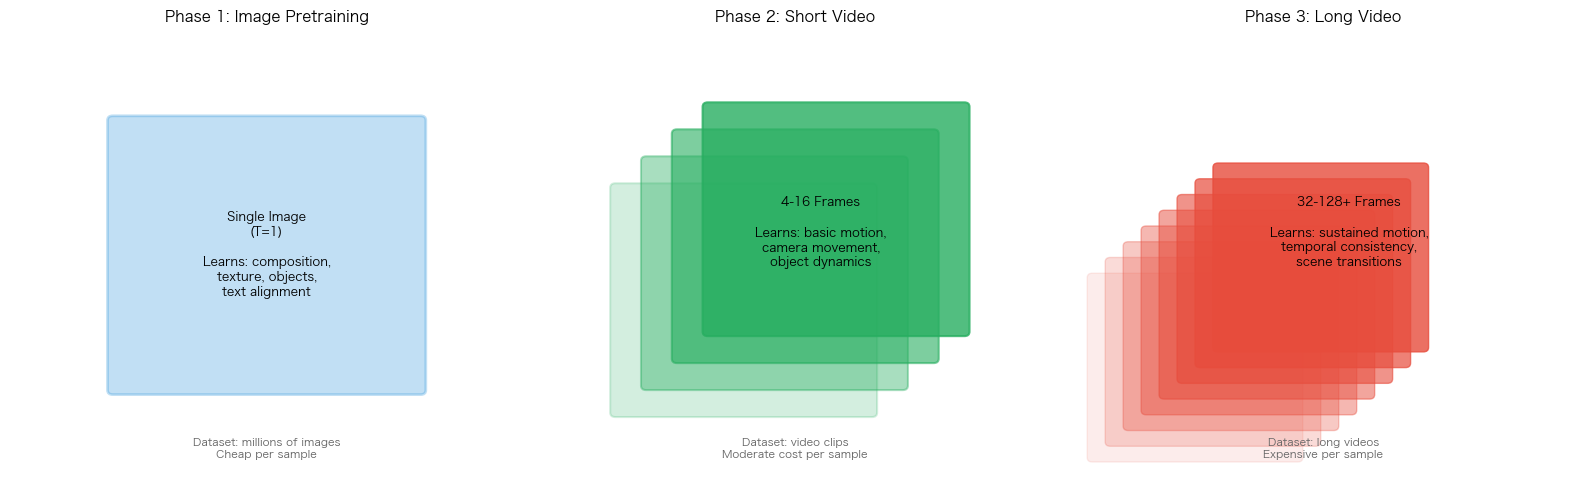

Each phase initializes from the previous phase's weights.
Temporal attention layers are added in Phase 2 and initialized to zero
(so the model initially ignores time and behaves like an image model).


In [11]:
# Visualize progressive training strategy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Phase 1: Image pretraining
ax = axes[0]
ax.set_title('Phase 1: Image Pretraining', fontsize=11, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Show single frame
rect = mpatches.FancyBboxPatch((2, 2), 6, 6, boxstyle="round,pad=0.1", 
                                 facecolor='#3498DB', alpha=0.3, edgecolor='#3498DB', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5, 'Single Image\n(T=1)\n\nLearns: composition,\ntexture, objects,\ntext alignment', 
        ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(5, 0.5, 'Dataset: millions of images\nCheap per sample', ha='center', fontsize=8, color='#666')

# Phase 2: Short video
ax = axes[1]
ax.set_title('Phase 2: Short Video', fontsize=11, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

for i, offset in enumerate([0, 0.6, 1.2, 1.8]):
    alpha = 0.2 + i * 0.2
    rect = mpatches.FancyBboxPatch((1.5 + offset, 1.5 + offset), 5, 5, 
                                     boxstyle="round,pad=0.1", facecolor='#27AE60', alpha=alpha,
                                     edgecolor='#27AE60', linewidth=1.5)
    ax.add_patch(rect)
ax.text(5.5, 5.5, '4-16 Frames\n\nLearns: basic motion,\ncamera movement,\nobject dynamics', 
        ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(5, 0.5, 'Dataset: video clips\nModerate cost per sample', ha='center', fontsize=8, color='#666')

# Phase 3: Long video
ax = axes[2]
ax.set_title('Phase 3: Long Video', fontsize=11, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

for i in range(8):
    offset = i * 0.35
    alpha = 0.1 + i * 0.1
    rect = mpatches.FancyBboxPatch((0.5 + offset, 0.5 + offset), 4, 4,
                                     boxstyle="round,pad=0.1", facecolor='#E74C3C', alpha=min(alpha, 0.8),
                                     edgecolor='#E74C3C', linewidth=1)
    ax.add_patch(rect)
ax.text(5.5, 5.5, '32-128+ Frames\n\nLearns: sustained motion,\ntemporal consistency,\nscene transitions', 
        ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(5, 0.5, 'Dataset: long videos\nExpensive per sample', ha='center', fontsize=8, color='#666')

plt.tight_layout()
plt.show()

print("Each phase initializes from the previous phase's weights.")
print("Temporal attention layers are added in Phase 2 and initialized to zero")
print("(so the model initially ignores time and behaves like an image model).")

In [12]:
# How temporal layers are initialized for progressive training
class TemporalAttentionLayer(nn.Module):
    """Temporal attention with zero-initialization for progressive training.
    
    When first added (Phase 2), this layer outputs zeros -- so the model
    initially behaves exactly like the image model from Phase 1.
    The temporal relationships are learned gradually.
    """
    def __init__(self, dim, n_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.scale = self.head_dim ** -0.5
        
        # Zero-initialize output projection so layer starts as identity
        nn.init.zeros_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)
        
        # Learnable gate, initialized to 0
        self.gate = nn.Parameter(torch.zeros(1))
    
    def forward(self, x, T):
        """
        x: (B, T*S, D) where S = spatial tokens per frame
        T: number of frames
        """
        B, N, D = x.shape
        S = N // T
        
        # Reshape for temporal attention: (B*S, T, D)
        h = self.norm(x)
        h = h.reshape(B, T, S, D).permute(0, 2, 1, 3).reshape(B * S, T, D)
        
        # Standard attention
        qkv = self.qkv(h).reshape(B * S, T, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B * S, T, D)
        out = self.proj(out)
        
        # Reshape back: (B*S, T, D) -> (B, T*S, D)
        out = out.reshape(B, S, T, D).permute(0, 2, 1, 3).reshape(B, N, D)
        
        # Gated residual (gate starts at 0 -> identity)
        return x + self.gate * out

# Demo: show that initial output is identity
torch.manual_seed(42)
temporal_layer = TemporalAttentionLayer(dim=128, n_heads=4)

B, T, S, D = 2, 8, 16, 128
x = torch.randn(B, T * S, D)

with torch.no_grad():
    out = temporal_layer(x, T=T)

print(f"Gate value (initial): {temporal_layer.gate.item():.4f}")
print(f"Max difference from identity: {(out - x).abs().max().item():.8f}")
print("\nAt initialization, the temporal layer is a perfect identity function!")
print("The model behaves exactly like the pretrained image model.")
print("As training progresses, the gate opens and temporal attention takes effect.")

Gate value (initial): 0.0000
Max difference from identity: 0.00000000

At initialization, the temporal layer is a perfect identity function!
The model behaves exactly like the pretrained image model.
As training progresses, the gate opens and temporal attention takes effect.


---
## 五、时间一致性

纵有良好之架构，视频生成仍受特征性瑕疵所困。明此等瑕疵，方能体会工程之挑战。

### 常见瑕疵

| 瑕疵 | 表现 | 成因 |
|------|------|------|
| **闪烁** | 帧间亮度或色彩变化 | 时间注意力不足，帧间噪声独立 |
| **物体漂移** | 物体渐变形状或位置 | 长距时间依赖未被捕捉 |
| **时间混叠** | 动作生硬或卡顿 | 时间分辨率不足，帧插值不当 |
| **身份偏移** | 人脸渐变 | 注意力未能跨长序列维持身份 |
| **背景不一致** | 背景帧间变化 | 空间注意力偏重前景，忽略背景 |

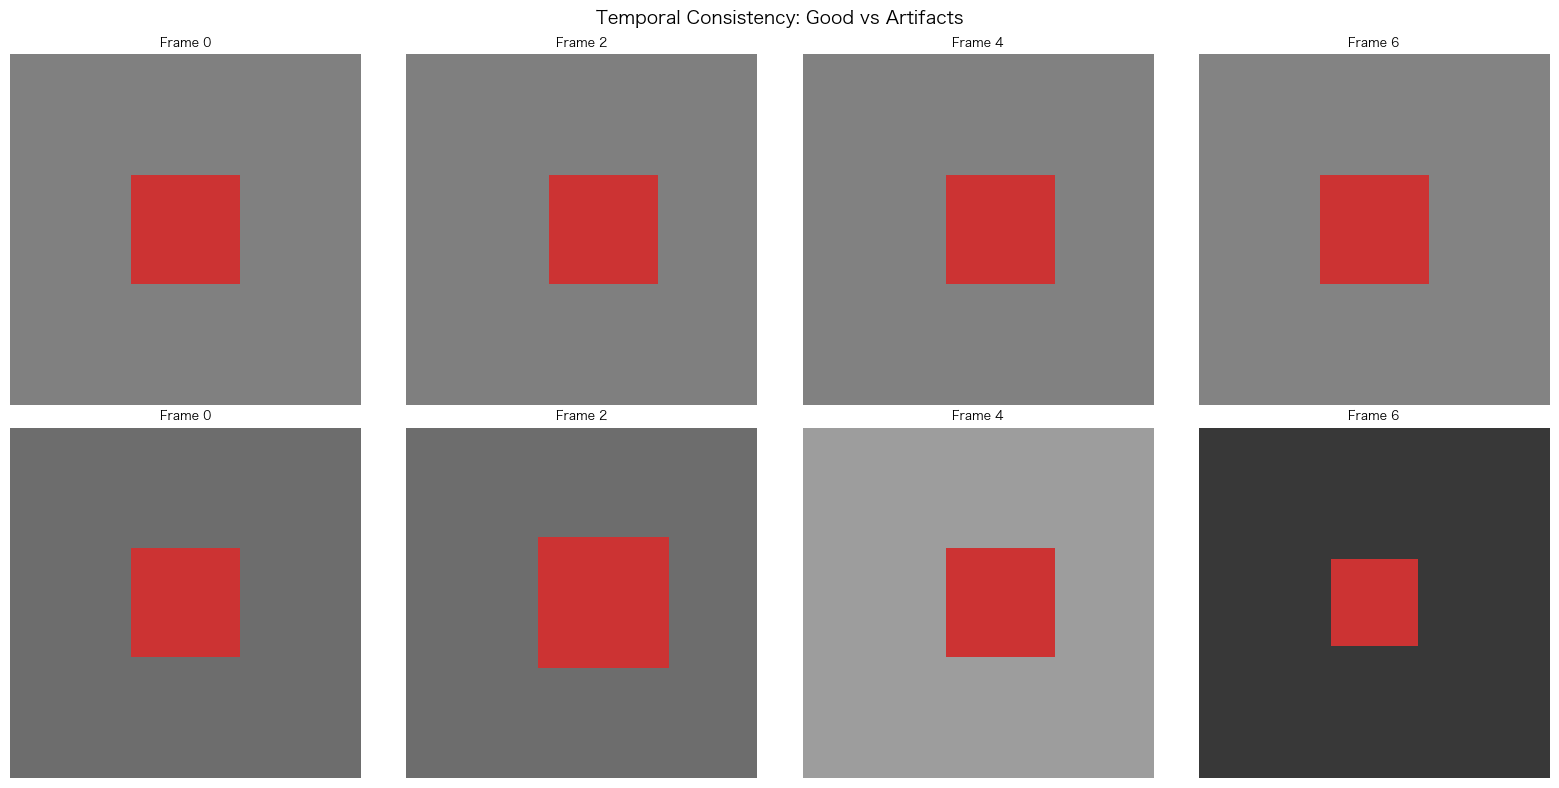

Solutions to temporal inconsistency:
1. Stronger temporal attention (more layers, longer context)
2. Temporal conditioning (pass previous frame features as context)
3. Frame interpolation (generate keyframes, interpolate between)
4. Classifier-free guidance with temporal regularization


In [13]:
# Simulate and visualize temporal artifacts

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
np.random.seed(42)
T = 8  # frames

# Row 1: Good temporal consistency
axes[0, 0].set_ylabel('Good\n(consistent)', fontsize=11, fontweight='bold')
base_signal = np.sin(np.linspace(0, 2 * np.pi, T))
for i in range(T):
    x = np.linspace(0, 1, 20)
    y = 0.5 + 0.3 * np.sin(2 * np.pi * x + base_signal[i])
    axes[0, i // 2 * 0 + 0 if i < 4 else 1].clear() if False else None
    
# Actually, let's show this more simply
for row, (label, noise_std) in enumerate([(f'Consistent (noise=0.01)', 0.01), (f'Flickering (noise=0.3)', 0.3)]):
    base_brightness = 0.5
    for i in range(4):
        ax = axes[row, i]
        frame_idx = i * 2  # show frames 0, 2, 4, 6
        
        # Create a simple "object" (circle) with potential flicker
        img = np.ones((32, 32, 3)) * (base_brightness + np.random.normal(0, noise_std))
        img = np.clip(img, 0, 1)
        
        # Draw a "circle" (square for simplicity)
        cx, cy = 16 + int(3 * np.sin(frame_idx * 0.5)), 16
        size = 5
        if row == 1 and np.random.random() > 0.5:
            size += np.random.randint(-2, 3)  # object drift
        img[cy-size:cy+size, cx-size:cx+size] = [0.8, 0.2, 0.2]
        
        ax.imshow(img)
        ax.set_title(f'Frame {frame_idx}', fontsize=9)
        ax.axis('off')
    
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')

plt.suptitle('Temporal Consistency: Good vs Artifacts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Solutions to temporal inconsistency:")
print("1. Stronger temporal attention (more layers, longer context)")
print("2. Temporal conditioning (pass previous frame features as context)")
print("3. Frame interpolation (generate keyframes, interpolate between)")
print("4. Classifier-free guidance with temporal regularization")

In [14]:
info_box(
    """<b>时间一致性之工程对策</b><br><br>
    <b>一、强化时间注意力</b><br>
    - 用<i>因果</i>时间注意力（各帧仅可见先前之帧）<br>
    - 于<i>每一</i>分辨率层皆加时间注意力，非仅瓶颈层<br><br>
    <b>二、运动条件注入</b><br>
    - 以光流或运动向量为条件<br>
    - 将运动幅度作为独立输入学习（用户可控速度）<br><br>
    <b>三、帧插值</b><br>
    - 先以低帧率（4-8 fps）生成关键帧<br>
    - 再以独立之插值模型生成平滑高帧率输出<br>
    - 远廉于一次生成所有帧<br><br>
    <b>四、多尺度时间处理</b><br>
    - 粗运动于低分辨率处理，精细细节于高分辨率处理<br>
    - 与 UNet 之空间多尺度处理类似""",
    title="工程之法"
)

---
## 六、内存工程

视频生成将 GPU 内存推至极限。以下为使之可行之关键术法。

### 梯度检查点

训练时，常规做法须存储所有中间激活以供反向传播。于视频，此代价过巨不可承受。**梯度检查点**于前向传播时丢弃中间激活，于反向传播时重新计算：

- **不用检查点**：存储全部 N 层之激活 -> O(N) 内存
- **用检查点**：仅于检查点处存激活，余者重算 -> O(sqrt(N)) 内存
- **代价**：计算量约增 33%（反向传播时须重算激活）

In [15]:
# Gradient checkpointing: memory vs compute tradeoff
n_layers_list = [12, 24, 28, 48, 64]
activation_per_layer_gb = 0.5  # approximate for video

print(f"{'Layers':>8} | {'No Checkpoint':>15} | {'Checkpoint (sqrt)':>18} | {'Savings':>10} | {'Extra Compute':>15}")
print("-" * 80)

for n in n_layers_list:
    no_ckpt = n * activation_per_layer_gb
    # With sqrt(n) checkpoints, store sqrt(n) activations + recompute up to sqrt(n) per segment
    ckpt_segments = int(math.sqrt(n))
    ckpt_mem = (ckpt_segments + n // ckpt_segments) * activation_per_layer_gb
    savings = (1 - ckpt_mem / no_ckpt) * 100
    extra_compute = 33  # roughly constant overhead
    print(f"{n:>8} | {no_ckpt:>12.1f} GB | {ckpt_mem:>15.1f} GB | {savings:>8.0f}% | ~{extra_compute}%")

print("\nGradient checkpointing is essential for video generation training.")
print("Most production models checkpoint every 1-4 layers.")

  Layers |   No Checkpoint |  Checkpoint (sqrt) |    Savings |   Extra Compute
--------------------------------------------------------------------------------
      12 |          6.0 GB |             3.5 GB |       42% | ~33%
      24 |         12.0 GB |             5.0 GB |       58% | ~33%
      28 |         14.0 GB |             5.0 GB |       64% | ~33%
      48 |         24.0 GB |             7.0 GB |       71% | ~33%
      64 |         32.0 GB |             8.0 GB |       75% | ~33%

Gradient checkpointing is essential for video generation training.
Most production models checkpoint every 1-4 layers.


In [16]:
# Full memory engineering toolkit for video
comparison_table(
    headers=["Technique", "Memory Savings", "Compute Cost", "Complexity"],
    rows=[
        ["Gradient Checkpointing", "50-70% activation savings", "+33% compute", "Low (PyTorch built-in)"],
        ["Mixed Precision (FP16/BF16)", "50% for activations + weights", "Often faster (tensor cores)", "Low"],
        ["Sequence Parallelism", "Split temporal dim across GPUs", "Communication overhead", "Medium"],
        ["Tensor Parallelism", "Split model weights across GPUs", "AllReduce per layer", "Medium"],
        ["Pipeline Parallelism", "Split layers across GPUs", "Pipeline bubbles", "High"],
        ["ZeRO Stage 1-3", "Split optimizer/gradient/params", "AllGather overhead", "Medium"],
        ["Temporal Chunking", "Process frames in chunks", "Some temporal loss", "Low"],
        ["VAE Tiling", "Encode/decode image tiles", "Tile boundary artifacts", "Low"],
    ],
    title="Memory Engineering Toolkit for Video Generation"
)

# Link to parallelism notebooks
print("\nFor details on these parallelism techniques, see:")
print("  - Tensor Parallelism: ../../en/02-tensor-parallelism.ipynb")
print("  - Pipeline Parallelism: ../../en/03-pipeline-parallelism.ipynb")
print("  - Sequence Parallelism: ../../en/04-sequence-parallelism.ipynb")
print("  - ZeRO Optimizer: ../../en/07-parallelism-mix-strategy.ipynb")

Technique,Memory Savings,Compute Cost,Complexity
Gradient Checkpointing,50-70% activation savings,+33% compute,Low (PyTorch built-in)
Mixed Precision (FP16/BF16),50% for activations + weights,Often faster (tensor cores),Low
Sequence Parallelism,Split temporal dim across GPUs,Communication overhead,Medium
Tensor Parallelism,Split model weights across GPUs,AllReduce per layer,Medium
Pipeline Parallelism,Split layers across GPUs,Pipeline bubbles,High
ZeRO Stage 1-3,Split optimizer/gradient/params,AllGather overhead,Medium
Temporal Chunking,Process frames in chunks,Some temporal loss,Low
VAE Tiling,Encode/decode image tiles,Tile boundary artifacts,Low



For details on these parallelism techniques, see:
  - Tensor Parallelism: ../../en/02-tensor-parallelism.ipynb
  - Pipeline Parallelism: ../../en/03-pipeline-parallelism.ipynb
  - Sequence Parallelism: ../../en/04-sequence-parallelism.ipynb
  - ZeRO Optimizer: ../../en/07-parallelism-mix-strategy.ipynb


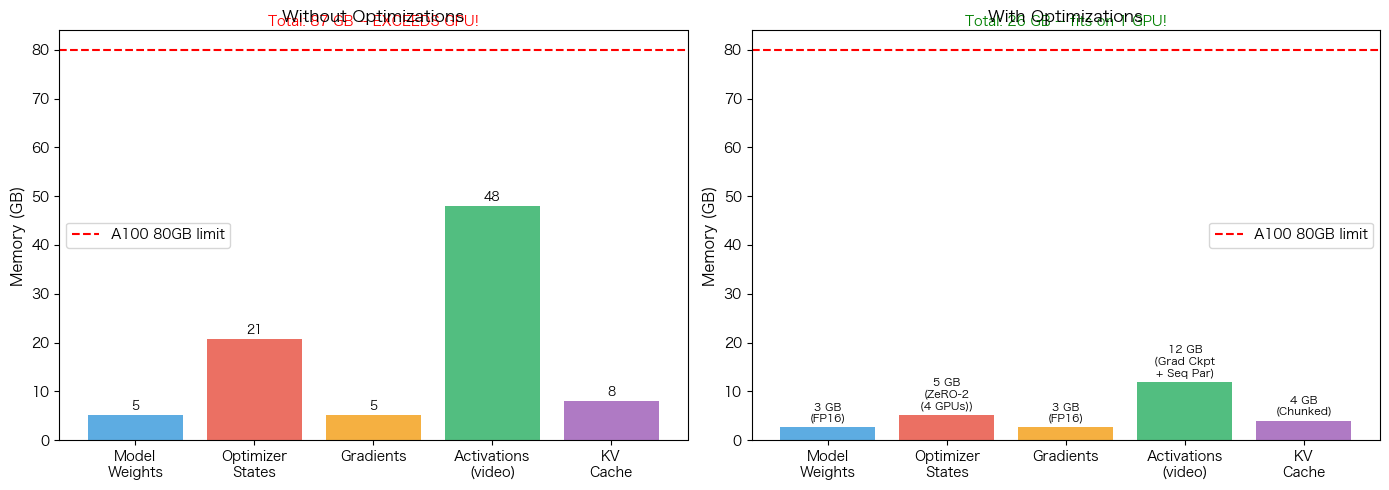

Memory reduction: 87 GB -> 26 GB (3.3x reduction)
Key techniques: FP16 weights, ZeRO-2, gradient checkpointing, sequence parallelism


In [17]:
# Realistic memory budget for training a video generation model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without optimizations
ax = axes[0]
categories = ['Model\nWeights', 'Optimizer\nStates', 'Gradients', 'Activations\n(video)', 'KV\nCache']
without_opt = [5.2, 20.8, 5.2, 48.0, 8.0]  # GB for ~2.6B param model, 16 frames
colors = ['#3498DB', '#E74C3C', '#F39C12', '#27AE60', '#9B59B6']
bars = ax.bar(categories, without_opt, color=colors, alpha=0.8)
ax.set_ylabel('Memory (GB)', fontsize=11)
ax.set_title('Without Optimizations', fontsize=12, fontweight='bold')
ax.axhline(y=80, color='red', linestyle='--', label='A100 80GB limit')
total_without = sum(without_opt)
ax.text(2, 85, f'Total: {total_without:.0f} GB -- EXCEEDS GPU!', fontsize=10, 
        color='red', fontweight='bold', ha='center')
ax.legend()
for bar, val in zip(bars, without_opt):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', 
            ha='center', fontsize=9, fontweight='bold')

# With optimizations
ax = axes[1]
with_opt = [2.6, 5.2, 2.6, 12.0, 4.0]  # FP16 weights, ZeRO-2, ckpt, seq parallel
bars = ax.bar(categories, with_opt, color=colors, alpha=0.8)
ax.set_ylabel('Memory (GB)', fontsize=11)
ax.set_title('With Optimizations', fontsize=12, fontweight='bold')
ax.axhline(y=80, color='red', linestyle='--', label='A100 80GB limit')
total_with = sum(with_opt)
ax.text(2, 85, f'Total: {total_with:.0f} GB -- fits on 1 GPU!', fontsize=10,
        color='green', fontweight='bold', ha='center')
ax.legend()

# Add optimization labels
opt_labels = ['FP16', 'ZeRO-2\n(4 GPUs)', 'FP16', 'Grad Ckpt\n+ Seq Par', 'Chunked']
for bar, val, opt in zip(bars, with_opt, opt_labels):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f} GB\n({opt})', 
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Memory reduction: {total_without:.0f} GB -> {total_with:.0f} GB ({total_without/total_with:.1f}x reduction)")
print("Key techniques: FP16 weights, ZeRO-2, gradient checkpointing, sequence parallelism")

---
## 总结

| 概念 | 要旨 |
|------|------|
| **视频即图像加时间** | 帧数之增使内存与计算线性（乃至更甚地）增长 |
| **分解注意力** | 拆为空间（帧内）与时间（跨帧），避 O((T*S)^2) 之巨耗 |
| **时空图块化** | 三维图块同时压缩空间与时间 |
| **渐进训练** | 图像预训练 -> 短视频 -> 长视频 |
| **时间一致性** | 品质之最大挑战；以强时间注意力与帧插值解之 |
| **内存工程** | 梯度检查点、混合精度、序列并行皆不可或缺 |

### 视频生成架构之比较

| 模型 | 架构 | 时间策略 | 核心优势 |
|------|------|----------|----------|
| **Sora** | 时空 DiT | 三维时空图块 | 可变分辨率与时长 |
| **CogVideo** | 专家 Transformer | 分解式专家注意力 | 以专家路由求效率 |
| **HunyuanVideo** | 全注意力 DiT | 因果三维 VAE 与联合注意力 | 强时间一致性 |

### 要义
- 视频生成之难，本质上既为**内存工程**之问题，亦为架构之问题
- 分解注意力避全三维注意力之二次代价，使视频生成可行
- 渐进训练不可或缺——先学视觉品质，后学运动
- 一切产用视频模型皆深度依赖分布式训练（张量并行、流水线并行与序列并行）

### 延伸阅读
- [Sora Technical Report (OpenAI, 2024)](https://openai.com/sora)
- [CogVideoX: Text-to-Video Diffusion Models with An Expert Transformer (2024)](https://arxiv.org/abs/2408.06072)
- [HunyuanVideo: A Systematic Framework For Large Video Generation Model (2024)](https://arxiv.org/abs/2412.03603)
- [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis (2024)](https://arxiv.org/abs/2403.03206)

### 前篇：[04 - DiT 架构](04-dit-architecture.ipynb) | [03 - 潜空间扩散](03-latent-diffusion.ipynb)